# 01 - Data Preparation & EDA

This notebook contains the complete feature extraction pipeline for your GNN and VAE models:
1. **Load data** and extract Lipinski descriptors  
2. **Visualize** molecular property distributions
3. **Convert SMILES to PyG graphs** with proper node/edge features
4. **Reference pocket encoding** for VAE conditioning
5. **Save processed data** for downstream notebooks

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn torch-geometric rdkit-pypi tensorboard biopython

# Imports and configuration
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen
import logging
import torch
from torch_geometric.data import Data

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parent
DATA_RAW = ROOT / 'data' / 'raw' / 'bioactivity'
DATA_PROCESSED = ROOT / 'data' / 'processed'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
OUT = ROOT / 'results' / 'figures'
OUT.mkdir(parents=True, exist_ok=True)

logger = logging.getLogger()
logger.setLevel(logging.INFO)
print('✓ Working directory:', ROOT)

✓ Working directory: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss


In [4]:
# Optional: Download ZINC subset (disabled by default)
DO_DOWNLOAD = False
if DO_DOWNLOAD:
    import requests
    url = 'https://raw.githubusercontent.com/aspuru-guzik-group/chemical_vae/master/data/zinc250k.smi'
    target = DATA_RAW / 'zinc250k.smi'
    res = requests.get(url, stream=True)
    with open(target, 'wb') as f:
        for chunk in res.iter_content(chunk_size=8192):
            f.write(chunk)
    print('Downloaded', target)
else:
    print('Download skipped (set DO_DOWNLOAD=True to enable)')

Download skipped (set DO_DOWNLOAD=True to enable)


In [5]:
# ===== LOAD DATA & EXTRACT GLOBAL FEATURES: Lipinski's Rule of 5 + ADME =====

def extract_global_features(smiles_list, pic50_list=None):
    """Extracts expanded molecular descriptors (Lipinski + ADME properties)."""
    rows = []
    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        row = {
            'SMILES': smiles,
            'MolWt': Descriptors.MolWt(mol),
            'LogP': Crippen.MolLogP(mol),
            'NumHDonors': Descriptors.NumHDonors(mol),
            'NumHAcceptors': Descriptors.NumHAcceptors(mol),
            'TPSA': Descriptors.TPSA(mol),                           # Topological polar surface area
            'RotatableBonds': Descriptors.NumRotatableBonds(mol),    # Molecular flexibility
        }
        if pic50_list is not None and i < len(pic50_list):
            row['pIC50'] = pic50_list[i]
        rows.append(row)
    return pd.DataFrame(rows)

# Load bioactivity data
raw_csv = DATA_RAW / 'egfr_full_standardized.csv'
if raw_csv.exists():
    df = pd.read_csv(raw_csv)
    print(f'✓ Loaded {raw_csv.name} with {len(df)} rows')
    pic50_list = df.get('pChEMBL_Value', None)
    df_global = extract_global_features(df['Smiles'].tolist(), pic50_list.tolist() if pic50_list is not None else None)
    print(f'\nGlobal Features Table (shape={df_global.shape}):')
    print(df_global.head())
else:
    print('⚠ Raw CSV not found; creating sample dataset')
    df = pd.DataFrame({
        'Smiles': ['CCO', 'CC(=O)O', 'CCN', 'CCCl', 'c1ccccc1'],
        'pChEMBL_Value': [6.5, 5.2, 7.1, 4.8, 6.9]
    })
    df_global = extract_global_features(df['Smiles'].tolist(), df['pChEMBL_Value'].tolist())
    print(f'Sample Data (shape={df_global.shape}):')
    print(df_global)


✓ Loaded egfr_full_standardized.csv with 20933 rows


[09:53:40] improperly formatted w block



Global Features Table (shape=(20909, 8)):
                                              SMILES    MolWt     LogP  \
0  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...  383.814  4.45034   
1  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...  482.903  3.61432   
2        CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12  369.432  4.77200   
3             CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1  283.287  2.31056   
4                             O=C(O)/C=C/c1ccc(O)cc1  164.160  1.49000   

   NumHDonors  NumHAcceptors    TPSA  RotatableBonds     pIC50  
0           3              4   82.70               3  7.387216  
1           3              6  112.24               4  6.769551  
2           1              6   78.66               6  5.031517  
3           2              4  113.98               5  3.301030  
4           2              2   57.53               2  2.522879  


In [6]:
# ===== FEATURE INSPECTION: describe().T and quality checks =====

from IPython.display import display

feature_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
feature_cols = [col for col in feature_cols if col in df_global.columns]

if feature_cols:
    df_property = df_global[feature_cols].copy()
    summary = df_property.describe().T
    summary['missing'] = df_property.isna().sum()
    summary['nunique'] = df_property.nunique()
    summary['skew'] = df_property.skew(numeric_only=True)
    summary['kurtosis'] = df_property.kurtosis(numeric_only=True)

    print('✓ Feature summary (describe().T):')
    display(summary)

    print('\n✓ Missing values by feature:')
    display(df_property.isna().sum().sort_values(ascending=False).to_frame('missing'))

    print('\n✓ First 10 rows of key descriptors:')
    display(df_property.head(10))
else:
    print('⚠ No numeric feature columns found for summary inspection')

✓ Feature summary (describe().T):


,count,mean,std,min,25%,50%,75%,max,missing,nunique,skew,kurtosis
MolWt,20909.0,485.237053,118.984268,110.112000,409.574,484.583000,557.706000,1452.395000,0,13034,0.843046,4.281174
LogP,20909.0,4.566682,1.422341,-5.994500,3.661,4.516300,5.452300,13.116500,0,13691,0.091533,1.006698
NumHDonors,20909.0,2.172414,1.230111,0.000000,1.000,2.000000,3.000000,24.000000,0,14,0.893297,6.435912
NumHAcceptors,20909.0,6.757425,2.189921,0.000000,5.000,7.000000,8.000000,20.000000,0,21,0.532630,1.923054
pIC50,20909.0,7.022984,1.420691,1.259637,6.000,7.142668,8.154902,17.299989,0,3866,-0.204831,-0.424263



✓ Missing values by feature:


,missing
MolWt,0
LogP,0
NumHDonors,0
NumHAcceptors,0
pIC50,0



✓ First 10 rows of key descriptors:


,MolWt,LogP,NumHDonors,NumHAcceptors,pIC50
0,383.814,4.45034,3,4,7.387216
1,482.903,3.61432,3,6,6.769551
2,369.432,4.77200,1,6,5.031517
3,283.287,2.31056,2,4,3.301030
4,164.160,1.49000,2,2,2.522879
5,215.168,1.73096,1,5,4.017729
6,539.999,3.22822,3,7,5.274905
7,249.222,1.40098,2,5,3.578396
8,236.234,1.55914,2,5,6.903090
9,186.170,1.52836,2,4,4.455932


In [3]:
# ===== DATA QUALITY: IQR-Based Outlier Removal =====

print('=' * 70)
print('OUTLIER DETECTION & REMOVAL (IQR Method)')
print('=' * 70)

# Columns to check for outliers
outlier_columns = ['pIC50', 'MolWt', 'LogP', 'TPSA', 'RotatableBonds']
outlier_columns = [col for col in outlier_columns if col in df_global.columns]

outlier_summary = {}

# Detect outliers using IQR method
for col in outlier_columns:
    Q1 = df_global[col].quantile(0.25)
    Q3 = df_global[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    n_outliers = len(df_global[(df_global[col] < lower_bound) | (df_global[col] > upper_bound)])
    outlier_summary[col] = {'count': n_outliers, 'lower': lower_bound, 'upper': upper_bound}
    
    print(f'\n{col}:')
    print(f'  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}')
    print(f'  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]')
    print(f'  Outliers: {n_outliers} molecules')

# Remove outliers
n_before = len(df_global)
for col in outlier_columns:
    Q1 = df_global[col].quantile(0.25)
    Q3 = df_global[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df_global = df_global[(df_global[col] >= lower_bound) & (df_global[col] <= upper_bound)]

n_after = len(df_global)
n_removed = n_before - n_after

print(f'\n{"─" * 70}')
print(f'✓ Removed {n_removed} outlier molecules ({100 * n_removed / n_before:.1f}%)')
print(f'✓ Final dataset: {n_after} molecules')
print(f'{"─" * 70}')

# Reset index
df_global.reset_index(drop=True, inplace=True)
df = df.iloc[df_global.index]  # Keep df aligned with df_global

print(f'\nCleaned Data Summary:')
print(df_global[outlier_columns].describe().T[['mean', 'std', 'min', 'max']])


OUTLIER DETECTION & REMOVAL (IQR Method)

pIC50:
  Q1=6.00, Q3=8.15, IQR=2.15
  Bounds: [2.77, 11.39]
  Outliers: 22 molecules

MolWt:
  Q1=409.57, Q3=557.71, IQR=148.13
  Bounds: [187.38, 779.90]
  Outliers: 383 molecules

LogP:
  Q1=3.66, Q3=5.45, IQR=1.79
  Bounds: [0.97, 8.14]
  Outliers: 323 molecules

TPSA:
  Q1=79.38, Q3=111.72, IQR=32.34
  Bounds: [30.87, 160.23]
  Outliers: 707 molecules

RotatableBonds:
  Q1=5.00, Q3=8.00, IQR=3.00
  Bounds: [0.50, 12.50]
  Outliers: 705 molecules

──────────────────────────────────────────────────────────────────────
✓ Removed 1410 outlier molecules (6.7%)
✓ Final dataset: 19499 molecules
──────────────────────────────────────────────────────────────────────

Cleaned Data Summary:
                      mean        std         min         max
pIC50             7.082598   1.397379    2.853872   11.221849
MolWt           477.605251  98.905354  189.170000  775.383000
LogP              4.560272   1.284489    1.019370    8.078820
TPSA             

✓ Pairplot sample size: 250
✓ Activity threshold (median pIC50): 7.20
✓ Saved pairplot: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/descriptor_pairplot.png


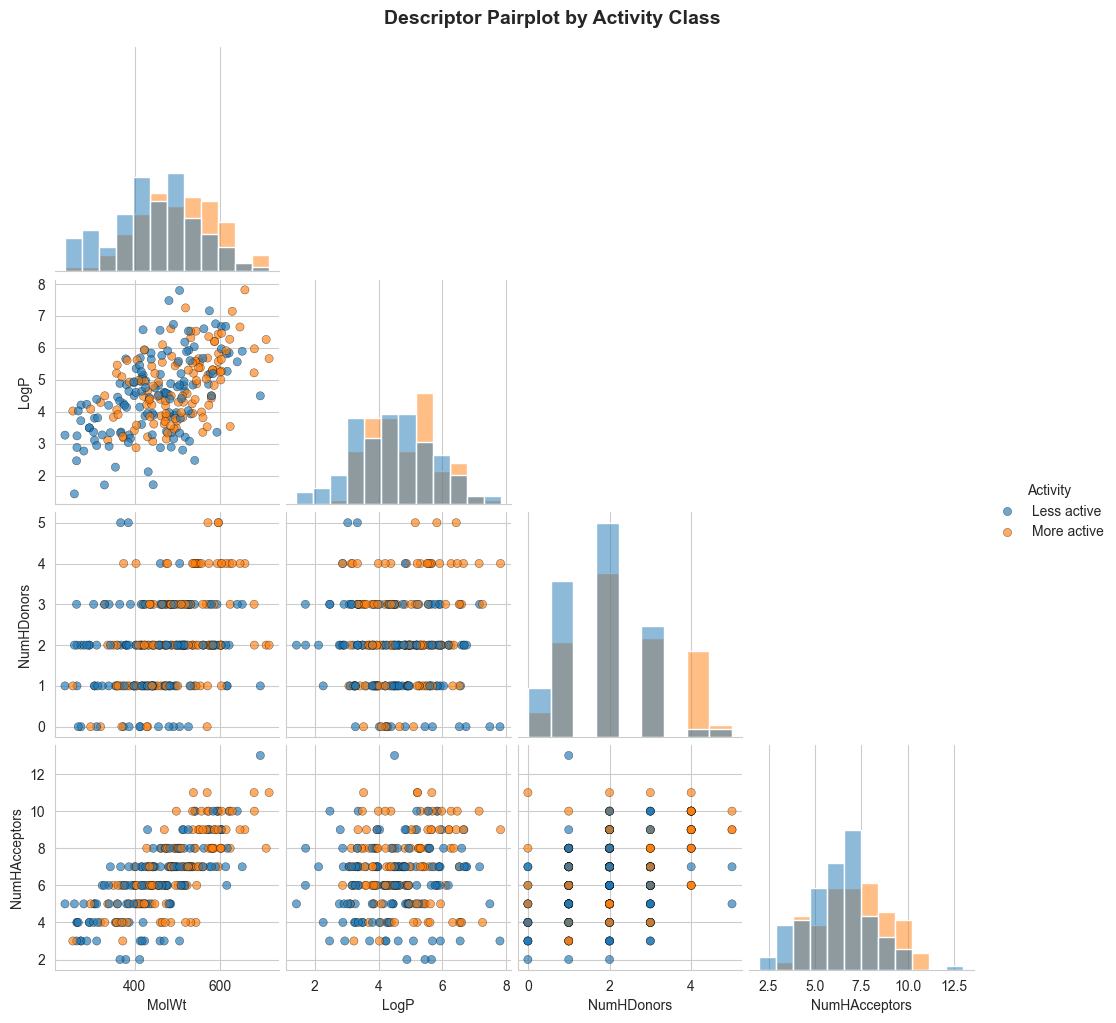


✓ Activity-stratified descriptor summary:


MolWt                          LogP                     \
                   mean   median        std      mean   median       std   
Activity                                                                   
Less active  449.186863  453.506  99.968600  4.327513  4.33600  1.301772   
More active  505.939234  512.204  89.242714  4.792339  4.69505  1.223778   

            NumHDonors                  NumHAcceptors                   \
                  mean median       std          mean median       std   
Activity                                                                 
Less active   1.956343    2.0  1.035354      6.153672    6.0  1.910847   
More active   2.318927    2.0  1.228184      7.114605    7.0  1.760142   

                pIC50                     
                 mean   median       std  
Activity                                  
Less active  5.916815  6.05700  0.855587  
More active  8.244918  8.21467  0.680886

/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_11245/3407360498.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=activity_df, x='Activity', y=feat, ax=ax, palette=['#f4a261', '#2a9d8f'])
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_11245/3407360498.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=activity_df, x='Activity', y=feat, ax=ax, palette=['#f4a261', '#2a9d8f'])
/var/folders/pc/8s1tc2r10qxbh34mff3zwvk80000gn/T/ipykernel_11245/3407360498.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(da

✓ Saved activity boxplots: /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/activity_boxplots.png


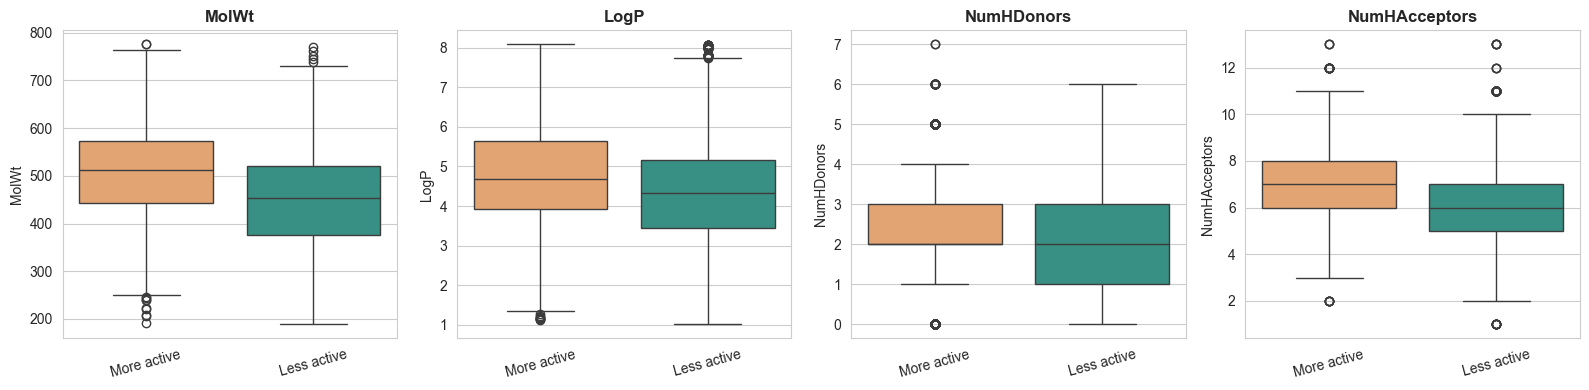

In [57]:
# ===== EDA EXTENSION: Pairplot and activity-stratified descriptor comparison =====

from IPython.display import display

eda_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
eda_cols = [col for col in eda_cols if col in df_global.columns]

if 'pIC50' in df_global.columns and len(eda_cols) >= 2:
    # Sample for readability and speed
    pairplot_df = df_global[eda_cols].dropna().sample(n=min(250, len(df_global.dropna(subset=eda_cols))), random_state=42)
    
    # Binary activity split around the median pIC50
    activity_threshold = df_global['pIC50'].median()
    pairplot_df = pairplot_df.copy()
    pairplot_df['Activity'] = np.where(pairplot_df['pIC50'] >= activity_threshold, 'More active', 'Less active')
    
    print(f'✓ Pairplot sample size: {len(pairplot_df)}')
    print(f'✓ Activity threshold (median pIC50): {activity_threshold:.2f}')
    
    # Pairplot colored by activity class
    pairplot = sns.pairplot(
        pairplot_df,
        vars=[c for c in eda_cols if c != 'pIC50'],
        hue='Activity',
        corner=True,
        diag_kind='hist',
        plot_kws={'alpha': 0.65, 's': 35, 'edgecolor': 'black', 'linewidth': 0.3}
    )
    pairplot.fig.suptitle('Descriptor Pairplot by Activity Class', y=1.02, fontsize=14, fontweight='bold')
    pairplot_out = OUT / 'descriptor_pairplot.png'
    pairplot.fig.savefig(pairplot_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved pairplot: {pairplot_out}')
    plt.show()
    
    # Activity-stratified descriptor summary
    activity_df = df_global[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']].dropna().copy()
    activity_df['Activity'] = np.where(activity_df['pIC50'] >= activity_threshold, 'More active', 'Less active')
    activity_summary = activity_df.groupby('Activity')[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']].agg(['mean', 'median', 'std'])
    print('\n✓ Activity-stratified descriptor summary:')
    display(activity_summary)
    
    # Boxplots for quick visual comparison
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    plot_features = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors']
    for ax, feat in zip(axes, plot_features):
        sns.boxplot(data=activity_df, x='Activity', y=feat, ax=ax, palette=['#f4a261', '#2a9d8f'])
        ax.set_title(feat, fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    boxplot_out = OUT / 'activity_boxplots.png'
    plt.savefig(boxplot_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved activity boxplots: {boxplot_out}')
else:
    print('⚠ pIC50 not available for activity-based pairplot analysis')

In [11]:
# ===== DRUG-LIKENESS EVALUATION: Lipinski's Rule of Five Analysis =====

def evaluate_drug_likeness(smiles):
    """Evaluates a molecule against Lipinski's Rule of Five (RO5)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Calculate properties
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    # Count RO5 violations
    violations = 0
    violation_details = []
    
    if mw > 500:
        violations += 1
        violation_details.append('MW > 500')
    if logp > 5:
        violations += 1
        violation_details.append('LogP > 5')
    if hbd > 5:
        violations += 1
        violation_details.append('HBD > 5')
    if hba > 10:
        violations += 1
        violation_details.append('HBA > 10')
    
    ro5_pass = violations <= 1  # RO5 allows max 1 violation for some drug classes
    
    return {
        'MW': mw,
        'LogP': logp,
        'HBD': hbd,
        'HBA': hba,
        'RO5_Violations': violations,
        'RO5_Pass': ro5_pass,
        'Violation_Details': ', '.join(violation_details) if violation_details else 'None'
    }

# Evaluate drug-likeness for all molecules
print('\n' + '=' * 70)
print('DRUG-LIKENESS EVALUATION (Lipinski\'s Rule of Five)')
print('=' * 70)

drug_likeness_data = []
for idx, row in df_global.iterrows():
    result = evaluate_drug_likeness(row['SMILES'])
    if result:
        result['Index'] = idx
        drug_likeness_data.append(result)

drug_likeness_df = pd.DataFrame(drug_likeness_data)

# Summary statistics
if len(drug_likeness_df) > 0:
    print(f'\nRO5 Violation Distribution:')
    violation_counts = drug_likeness_df['RO5_Violations'].value_counts().sort_index()
    for violations, count in violation_counts.items():
        pct = 100 * count / len(drug_likeness_df)
        pass_status = '✓ PASS' if violations <= 1 else '✗ FAIL'
        print(f'  {violations} violation(s): {count:5d} molecules ({pct:5.1f}%) {pass_status}')
    
    # RO5 Pass rate
    pass_count = (drug_likeness_df['RO5_Violations'] <= 1).sum()
    fail_count = len(drug_likeness_df) - pass_count
    print(f'\n  Drug-like (≤1 violation): {pass_count} ({100 * pass_count / len(drug_likeness_df):.1f}%)')
    print(f'  Non-drug-like (>1 violation): {fail_count} ({100 * fail_count / len(drug_likeness_df):.1f}%)')
    
    # Property distributions
    print(f'\nProperty Ranges ({len(drug_likeness_df)} molecules):')
    for col in ['MW', 'LogP', 'HBD', 'HBA']:
        mean_val = drug_likeness_df[col].mean()
        std_val = drug_likeness_df[col].std()
        min_val = drug_likeness_df[col].min()
        max_val = drug_likeness_df[col].max()
        print(f'  {col:4s}: {mean_val:6.1f} ± {std_val:5.1f}  (range: {min_val:6.1f} – {max_val:6.1f})')
    
    print('=' * 70)
else:
    print('⚠ No valid molecules for drug-likeness evaluation')



DRUG-LIKENESS EVALUATION (Lipinski's Rule of Five)

RO5 Violation Distribution:
  0 violation(s):  9351 molecules ( 44.7%) ✓ PASS
  1 violation(s):  5812 molecules ( 27.8%) ✓ PASS
  2 violation(s):  5377 molecules ( 25.7%) ✗ FAIL
  3 violation(s):   357 molecules (  1.7%) ✗ FAIL
  4 violation(s):    12 molecules (  0.1%) ✗ FAIL

  Drug-like (≤1 violation): 15163 (72.5%)
  Non-drug-like (>1 violation): 5746 (27.5%)

Property Ranges (20909 molecules):
  MW  :  485.2 ± 119.0  (range:  110.1 – 1452.4)
  LogP:    4.6 ±   1.4  (range:   -6.0 –   13.1)
  HBD :    2.2 ±   1.2  (range:    0.0 –   24.0)
  HBA :    6.8 ±   2.2  (range:    0.0 –   20.0)


✓ Saved /Users/ameliaburton/Downloads/clean data/clean_data_diss/results/figures/lipinski_distributions.png


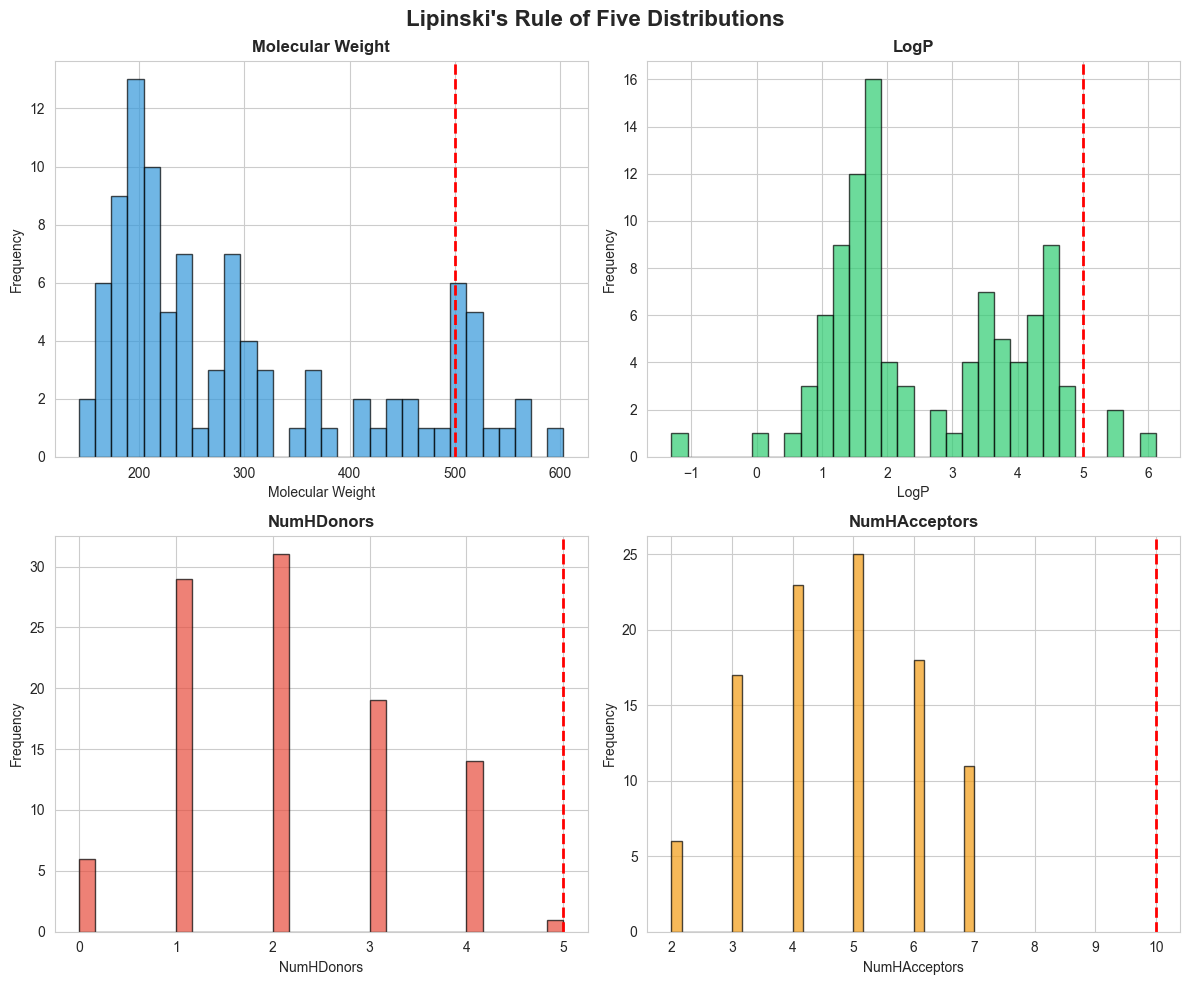

In [58]:
# ===== VISUALIZE: Lipinski's Rule of 5 Distributions =====

def compute_lipinski(smiles_list):
    rows = []
    for s in smiles_list:
        try:
            m = Chem.MolFromSmiles(s)
            if m is None:
                continue
            rows.append({
                'SMILES': s,
                'Molecular Weight': Descriptors.MolWt(m),
                'LogP': Crippen.MolLogP(m),
                'NumHDonors': Descriptors.NumHDonors(m),
                'NumHAcceptors': Descriptors.NumHAcceptors(m),
            })
        except Exception:
            continue
    return pd.DataFrame(rows)

desc_df = compute_lipinski(df['Smiles'].tolist()[:100])
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Lipinski's Rule of Five Distributions", fontsize=16, fontweight='bold')
axes = axes.ravel()
cols = ['Molecular Weight', 'LogP', 'NumHDonors', 'NumHAcceptors']
lims = [500, 5, 5, 10]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
for i, c in enumerate(cols):
    axes[i].hist(desc_df[c].dropna(), bins=30, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(c, fontweight='bold')
    axes[i].set_xlabel(c)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(lims[i], color='red', linestyle='--', linewidth=2)
plt.tight_layout()
out_file = OUT / 'lipinski_distributions.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight')
print(f'✓ Saved {out_file}')

Computing Morgan fingerprints for 200 molecules...


[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerator
[09:53:57] DEPRECATION WARNING: please use MorganGenerat

✓ Generated fingerprints: shape (200, 1024)
✓ PCA explained variance: 11.8%
✓ Saved chemical space plot: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\chemical_space_pca.png


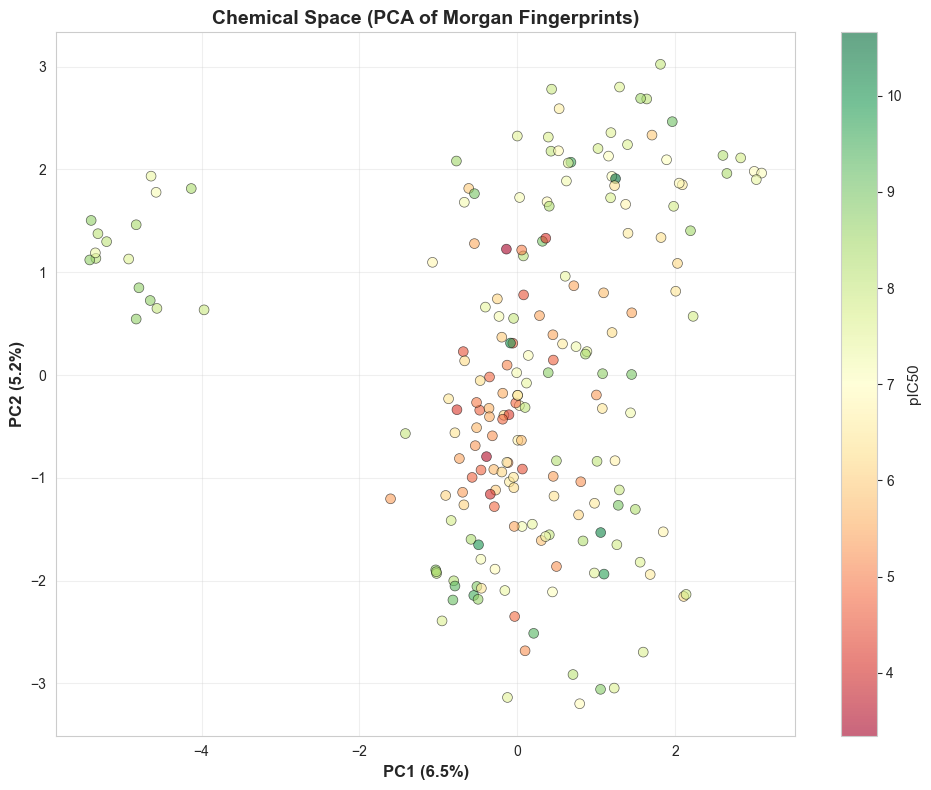

In [7]:
# ===== CHEMICAL SPACE: PCA OF MORGAN FINGERPRINTS =====

from rdkit.Chem import AllChem
from sklearn.decomposition import PCA

# Sample molecules for fingerprinting (limit to 200 for speed)
sample_size = min(200, len(df))
sample_mols = df['Smiles'].astype(str).sample(n=sample_size, random_state=42).tolist()

print(f'Computing Morgan fingerprints for {len(sample_mols)} molecules...')

fingerprints = []
valid_pic50 = []
for i, smiles in enumerate(sample_mols):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        fingerprints.append(fp)
        # Get corresponding pIC50 if available
        if 'pChEMBL_Value' in df.columns:
            idx_in_orig = df[df['Smiles'] == smiles].index[0] if smiles in df['Smiles'].values else None
            if idx_in_orig is not None and not pd.isna(df.loc[idx_in_orig, 'pChEMBL_Value']):
                valid_pic50.append(df.loc[idx_in_orig, 'pChEMBL_Value'])
            else:
                valid_pic50.append(None)
        else:
            valid_pic50.append(None)

# Convert fingerprints to dense array
fp_array = np.array([np.array(list(fp)) for fp in fingerprints])
print(f'✓ Generated fingerprints: shape {fp_array.shape}')

# PCA to 2D
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(fp_array)
print(f'✓ PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}')

# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Color by pIC50 if available
if any(v is not None for v in valid_pic50):
    pic50_vals = np.array([v if v is not None else np.nan for v in valid_pic50])
    valid_mask = ~np.isnan(pic50_vals)
    scatter = ax.scatter(pca_coords[valid_mask, 0], pca_coords[valid_mask, 1],
                        c=pic50_vals[valid_mask], cmap='RdYlGn', s=50, alpha=0.6,
                        edgecolors='black', linewidth=0.5)
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('pIC50', fontsize=11)
    # Plot non-active points in gray
    unmapped = ~valid_mask
    if unmapped.any():
        ax.scatter(pca_coords[unmapped, 0], pca_coords[unmapped, 1],
                  c='lightgray', s=30, alpha=0.3, edgecolors='none')
else:
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c='#3498db', s=50, alpha=0.6,
              edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12, fontweight='bold')
ax.set_title('Chemical Space (PCA of Morgan Fingerprints)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
out_file = OUT / 'chemical_space_pca.png'
plt.savefig(out_file, dpi=300, bbox_inches='tight')
print(f'✓ Saved chemical space plot: {out_file}')

In [8]:
# ===== TOP ACTIVES GRID: 2D STRUCTURES WITH CHEMICAL NAMES =====

from rdkit.Chem import Draw
import pubchempy as pcp

if 'pIC50' in df_global.columns and len(df) > 0:
    # Sort by pIC50 and get top 8 molecules
    top_n = 8
    top_actives = df_global.nlargest(top_n, 'pIC50')
    
    # Convert SMILES to molecules and fetch chemical names
    mols_list = []
    legends_list = []
    chem_data = []
    
    for idx, row in top_actives.iterrows():
        mol = Chem.MolFromSmiles(row['SMILES'])
        if mol is not None:
            mols_list.append(mol)
            
            # Try to fetch IUPAC name from PubChem
            try:
                compounds = pcp.get_compounds(row['SMILES'], namespace='smiles')
                if compounds:
                    iupac_name = compounds[0].iupac_name
                    # Shorten long names
                    names = [iupac_name.split(')')[-1], iupac_name.split(']')[-1]]
                    short_name = min(names, key=len)[:20]  # Truncate to 20 chars for display
                else:
                    short_name = f"pIC50: {row['pIC50']:.2f}"
            except Exception:
                short_name = f"pIC50: {row['pIC50']:.2f}"
            
            legends_list.append(short_name)
            chem_data.append({
                'Rank': len(chem_data) + 1,
                'pIC50': row['pIC50'],
                'MW': row['MolWt'],
                'LogP': row['LogP'],
                'Name': short_name,
                'SMILES': row['SMILES']
            })
    
    if mols_list:
        # Create grid image
        grid_img = Draw.MolsToGridImage(mols_list, molsPerRow=4, subImgSize=(200, 200),
                                        legends=legends_list, returnPNG=False)
        
        # Save image
        out_file = OUT / 'top_actives_grid.png'
        grid_img.save(out_file)
        print(f'✓ Saved top actives grid (n={len(mols_list)}): {out_file}')
        
        # Print detailed table
        print(f'\nTop {len(chem_data)} Most Potent Compounds:')
        print('─' * 80)
        for data in chem_data:
            print(f"  {data['Rank']}. {data['Name']}")
            print(f"     pIC50={data['pIC50']:.2f} | MW={data['MW']:.1f} | LogP={data['LogP']:.2f}")
            print(f"     SMILES: {data['SMILES'][:60]}...")
        print('─' * 80)
    else:
        print('⚠ Could not parse SMILES for top actives')
else:
    print('⚠ Insufficient data for top actives visualization')


✓ Saved top actives grid (n=8): c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\top_actives_grid.png

Top 8 Most Potent Compounds:
────────────────────────────────────────────────────────────────────────────────
  1. -1,4-dihydro-1,2,4-t
     pIC50=17.30 | MW=351.4 | LogP=1.48
     SMILES: C=CC(=O)N1CC[C@H](Oc2nc(-c3n[nH]c(=O)[nH]3)cc3ccccc23)C1...
  2. quinazolin-4-amine
     pIC50=11.52 | MW=350.2 | LogP=5.29
     SMILES: Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1...
  3. -6,7-diethoxyquinazo
     pIC50=11.22 | MW=388.3 | LogP=4.93
     SMILES: CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC...
  4. pyrimidine-4,6-diami
     pIC50=11.10 | MW=330.2 | LogP=3.57
     SMILES: CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1...
  5. pIC50: 11.10
     pIC50=11.10 | MW=340.2 | LogP=4.01
     SMILES: Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1...
  6. pyrimidine-5-carboxy
     pIC50=11.10 | MW=562.7 | LogP=6.13
     SMILES: COc1cc(N2CCC(N(C)C)CC2)ccc1Nc1ncc(C(=O)Oc2ccccc2)c(-c2c[nH]c...
  7. quinazolin

✓ Saved correlation heatmap: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\descriptor_correlation_heatmap.png

Correlation with pIC50:
pIC50            1.000000
MolWt            0.257870
NumHAcceptors    0.227447
LogP             0.207528
NumHDonors       0.101836
Name: pIC50, dtype: float64


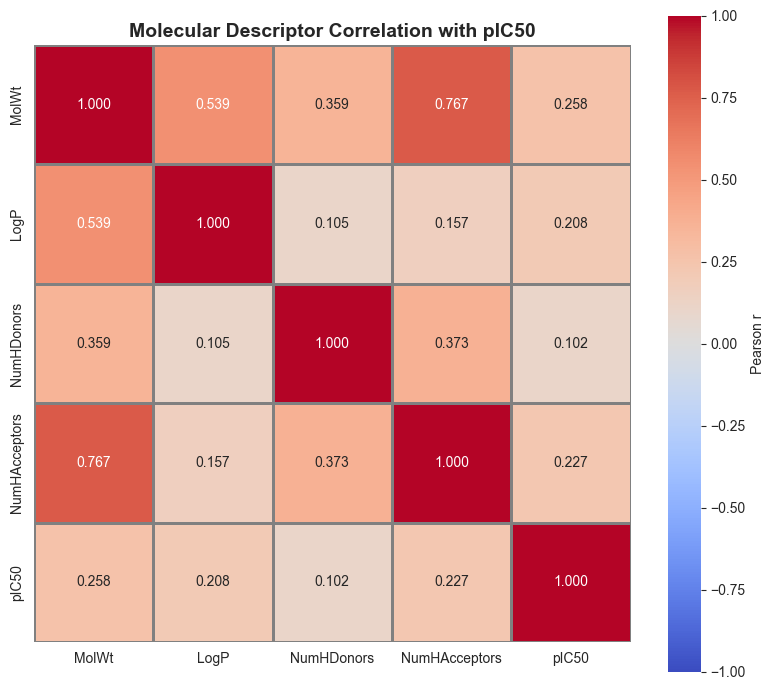

In [9]:
# ===== DESCRIPTOR CORRELATION HEATMAP =====

if 'pIC50' in df_global.columns:
    # Select key descriptors
    corr_cols = ['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50']
    corr_data = df_global[corr_cols].dropna()
    
    # Compute Pearson correlation
    corr_matrix = corr_data.corr(method='pearson')
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
               vmin=-1, vmax=1, cbar_kws={'label': 'Pearson r'},
               square=True, linewidths=1, linecolor='gray', ax=ax)
    
    ax.set_title('Molecular Descriptor Correlation with pIC50', fontsize=14, fontweight='bold')
    plt.tight_layout()
    out_file = OUT / 'descriptor_correlation_heatmap.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f'✓ Saved correlation heatmap: {out_file}')
    print(f'\nCorrelation with pIC50:')
    print(corr_matrix['pIC50'].sort_values(ascending=False))
else:
    print('⚠ Cannot compute correlations: pIC50 column missing')

C:\Users\u2251865\AppData\Local\Temp\ipykernel_3504\1249380172.py:15: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\u2251865\AppData\Local\Temp\ipykernel_3504\1249380172.py:15: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\u2251865\AppData\Local\Temp\ipykernel_3504\1249380172.py:15: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\u2251865\AppData\Local\Temp\ipykernel_3504\1249380172.py:17: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(out_file, dpi=300, bbox_inches='tight')
C:\Users\u2251865\AppData\Local\Temp\ipykernel_3504\1249380172.py:17: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(out_file, dpi=300, bbox_inches='tight')
C:\Users\u2251865\AppData\Local\Temp\ipykernel_3504\1249380172.py:17: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) m

✓ Saved pIC50 distribution: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\pic50_distribution.png

pIC50 Statistics:
  Mean: 7.02
  Std:  1.42
  Min:  1.26
  Max:  17.30


c:\Users\u2251865\Documents\u2251865\NSCLC_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\u2251865\Documents\u2251865\NSCLC_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\u2251865\Documents\u2251865\NSCLC_project\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8325 (\N{SUBSCRIPT FIVE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


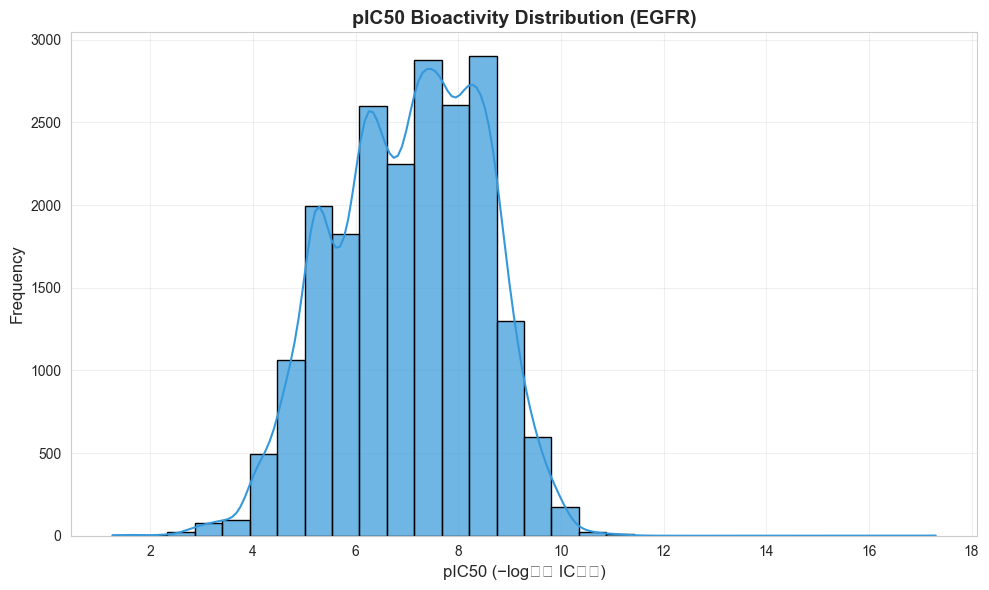

In [5]:
# ===== ADVANCED EDA: pIC50 BIOACTIVITY DISTRIBUTION =====

if 'pIC50' in df_global.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Histogram + KDE overlay
    sns.histplot(data=df_global, x='pIC50', kde=True, bins=30, 
                color='#3498db', edgecolor='black', alpha=0.7, ax=ax)
    
    ax.set_title('pIC50 Bioactivity Distribution (EGFR)', fontsize=14, fontweight='bold')
    ax.set_xlabel('pIC50 (−log₁₀ IC₅₀)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    out_file = OUT / 'pic50_distribution.png'
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f'✓ Saved pIC50 distribution: {out_file}')
    
    # Summary statistics
    print(f'\npIC50 Statistics:')
    print(f'  Mean: {df_global["pIC50"].mean():.2f}')
    print(f'  Std:  {df_global["pIC50"].std():.2f}')
    print(f'  Min:  {df_global["pIC50"].min():.2f}')
    print(f'  Max:  {df_global["pIC50"].max():.2f}')
else:
    print('⚠ pIC50 column not found in dataframe')

In [10]:
# ===== SMILES → PyG GRAPHS: Node & Edge Feature Extraction with 3D Coordinates =====

from rdkit.Chem import AllChem

def get_node_features(atom):
    """Extracts exactly 6 atomic features"""
    return [
        atom.GetAtomicNum(),       # e.g., 6=C, 8=O
        atom.GetTotalDegree(),     # Number of bonds
        atom.GetFormalCharge(),    # Electrical charge
        int(atom.GetHybridization()),  # SP/SP2/SP3  
        int(atom.GetIsAromatic()),  # Is aromatic?
        atom.GetMass()             # Atomic mass
    ]

def get_edge_features(bond):
    """Extracts 4-hot encoded bond types"""
    bond_type = bond.GetBondType()
    return [
        int(bond_type == Chem.rdchem.BondType.SINGLE),
        int(bond_type == Chem.rdchem.BondType.DOUBLE),
        int(bond_type == Chem.rdchem.BondType.TRIPLE),
        int(bond_type == Chem.rdchem.BondType.AROMATIC)
    ]

def smiles_to_graph(smiles):
    """Converts SMILES string to PyG Data object with 3D coordinates"""
    mol_base = Chem.MolFromSmiles(smiles)
    if mol_base is None:
        return None

    # Build the heavy-atom graph from the base molecule (stable path)
    mol = Chem.Mol(mol_base)
    x = [get_node_features(atom) for atom in mol.GetAtoms()]
    edge_index = [[], []]
    edge_attr = []

    for bond in mol.GetBonds():
        a1, a2 = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index[0].extend([a1, a2])
        edge_index[1].extend([a2, a1])
        features = get_edge_features(bond)
        edge_attr.extend([features, features])

    # Default to zero coordinates; overwrite if 3D generation succeeds
    coords_heavy = np.zeros((mol.GetNumAtoms(), 3), dtype=np.float32)

    try:
        mol_3d = Chem.AddHs(Chem.Mol(mol_base))
        embed_status = AllChem.EmbedMolecule(mol_3d, randomSeed=42)
        if embed_status == 0:
            try:
                AllChem.MMFFOptimizeMolecule(mol_3d)
            except Exception:
                pass

            conf = mol_3d.GetConformer()
            heavy_atom_indices = [a.GetIdx() for a in mol_3d.GetAtoms() if a.GetAtomicNum() > 1]
            coords = []
            for idx in heavy_atom_indices:
                p = conf.GetAtomPosition(idx)
                coords.append([p.x, p.y, p.z])

            if len(coords) == mol.GetNumAtoms():
                coords_heavy = np.array(coords, dtype=np.float32)
    except Exception:
        # Keep zero coordinates for rare molecules that fail 3D generation
        pass

    data = Data(
        x=torch.tensor(x, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        pos=torch.tensor(coords_heavy, dtype=torch.float)
    )
    return data

# Convert FULL EGFR dataset to graphs (no slice—process entire dataset)
sample_smiles = df['Smiles'].astype(str).tolist()
graphs = []
for s in sample_smiles:
    g = smiles_to_graph(s)
    if g is not None:
        graphs.append(g)

print(f'✓ Prepared {len(graphs)} PyG graphs with 3D coordinates (6 node + 4 edge features + 3D pos)')

# Save for downstream notebooks
if graphs:
    graph_file = DATA_PROCESSED / 'graph_data.pt'
    torch.save(graphs, str(graph_file))
    print(f'✓ Saved {len(graphs)} graphs to {graph_file}')

[09:55:33] UFFTYPER: Unrecognized charge state for atom: 2
[09:55:55] UFFTYPER: Unrecognized charge state for atom: 1
[09:56:27] UFFTYPER: Unrecognized charge state for atom: 1


KeyboardInterrupt: 

✓ Graph feature summary:


,Metric,Value
0,Graphs,1412.000000
1,Mean Nodes,26.982295
2,Median Nodes,26.000000
3,Mean Bonds,29.417139
4,Median Bonds,28.000000
5,Graphs with pos,1412.000000



✓ Most common atom types in the graph dataset:


,Atom,Atomic Number,Count
0,C,6,28028
1,N,7,5593
2,O,8,3102
3,Cl,17,404
4,Br,35,354
5,S,16,347
6,F,9,245
7,34,34,16
8,I,53,6
9,P,15,4



✓ Bond type distribution:


,Bond Type,Count
0,Single,14578
1,Double,1642
2,Triple,409
3,Aromatic,24908


✓ Saved graph feature EDA: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\graph_feature_eda.png

✓ 3D position coverage:
  Graphs with pos: 1412/1412
  Position dimensions: [3]


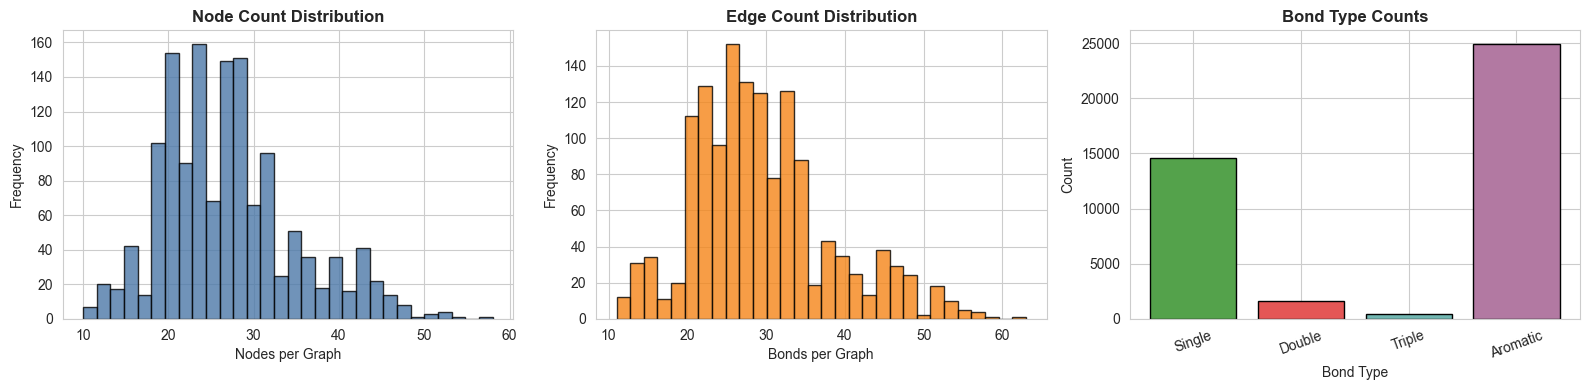

In [11]:
# ===== EDA: Graph Feature Inspection =====

from collections import Counter
from IPython.display import display

if 'graphs' in globals() and graphs:
    node_counts = []
    edge_counts = []
    atom_counter = Counter()
    bond_counter = Counter()
    pos_dims = []
    valid_pos_graphs = 0
    
    bond_type_names = ['Single', 'Double', 'Triple', 'Aromatic']
    
    for g in graphs:
        if hasattr(g, 'x') and g.x is not None:
            node_counts.append(g.x.shape[0])
            atom_nums = g.x[:, 0].detach().cpu().numpy().astype(int)
            atom_counter.update(atom_nums.tolist())
        
        if hasattr(g, 'edge_index') and g.edge_index is not None:
            n_edges = g.edge_index.shape[1] // 2 if g.edge_index.shape[1] > 0 else 0
            edge_counts.append(n_edges)
            if hasattr(g, 'edge_attr') and g.edge_attr is not None and g.edge_attr.shape[0] > 0:
                edge_types = g.edge_attr[::2].detach().cpu().numpy()
                bond_ids = np.argmax(edge_types, axis=1)
                bond_counter.update(bond_ids.tolist())
        
        if hasattr(g, 'pos') and g.pos is not None:
            pos_dims.append(g.pos.shape[1])
            valid_pos_graphs += 1
    
    atom_map = {
        1: 'H', 5: 'B', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 15: 'P', 16: 'S',
        17: 'Cl', 35: 'Br', 53: 'I', 30: 'Zn'
    }
    atom_rows = []
    for atomic_num, count in atom_counter.most_common(10):
        atom_rows.append({'Atom': atom_map.get(atomic_num, str(atomic_num)), 'Atomic Number': atomic_num, 'Count': count})
    atom_df = pd.DataFrame(atom_rows)
    bond_df = pd.DataFrame([
        {'Bond Type': bond_type_names[i], 'Count': bond_counter.get(i, 0)}
        for i in range(len(bond_type_names))
    ])
    
    graph_stats = pd.DataFrame({
        'Metric': ['Graphs', 'Mean Nodes', 'Median Nodes', 'Mean Bonds', 'Median Bonds', 'Graphs with pos'],
        'Value': [
            len(graphs),
            float(np.mean(node_counts)) if node_counts else np.nan,
            float(np.median(node_counts)) if node_counts else np.nan,
            float(np.mean(edge_counts)) if edge_counts else np.nan,
            float(np.median(edge_counts)) if edge_counts else np.nan,
            valid_pos_graphs,
        ]
    })
    
    print('✓ Graph feature summary:')
    display(graph_stats)
    
    print('\n✓ Most common atom types in the graph dataset:')
    display(atom_df)
    
    print('\n✓ Bond type distribution:')
    display(bond_df)
    
    # Visualize structural distributions
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    axes[0].hist(node_counts, bins=30, color='#4C78A8', edgecolor='black', alpha=0.8)
    axes[0].set_title('Node Count Distribution', fontweight='bold')
    axes[0].set_xlabel('Nodes per Graph')
    axes[0].set_ylabel('Frequency')
    
    axes[1].hist(edge_counts, bins=30, color='#F58518', edgecolor='black', alpha=0.8)
    axes[1].set_title('Edge Count Distribution', fontweight='bold')
    axes[1].set_xlabel('Bonds per Graph')
    axes[1].set_ylabel('Frequency')
    
    bond_counts = [bond_counter.get(i, 0) for i in range(4)]
    axes[2].bar(bond_type_names, bond_counts, color=['#54A24B', '#E45756', '#72B7B2', '#B279A2'], edgecolor='black')
    axes[2].set_title('Bond Type Counts', fontweight='bold')
    axes[2].set_xlabel('Bond Type')
    axes[2].set_ylabel('Count')
    axes[2].tick_params(axis='x', rotation=20)
    
    plt.tight_layout()
    graph_out = OUT / 'graph_feature_eda.png'
    plt.savefig(graph_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved graph feature EDA: {graph_out}')
    
    # 3D position coverage check
    if valid_pos_graphs > 0:
        pos_dims = pd.Series(pos_dims)
        print('\n✓ 3D position coverage:')
        print(f'  Graphs with pos: {valid_pos_graphs}/{len(graphs)}')
        print(f'  Position dimensions: {pos_dims.unique().tolist()}')
else:
    print('⚠ Graphs are not available yet; run the graph generation cell first')

In [8]:
# ===== POCKET FEATURES: 3D Protein Structure Encoding =====

def compute_pocket_tensor(coords, embedding_dim=128):
    """Squashes variable-sized protein pocket into 128-dim fixed embedding"""
    if coords.size == 0:
        return torch.zeros(embedding_dim, dtype=torch.float32)
    
    centroid = coords.mean(axis=0)
    std_dev = coords.std(axis=0)
    max_spread = coords.max(axis=0) - coords.min(axis=0)
    
    feat = np.concatenate([centroid, std_dev, max_spread])
    feat = np.pad(feat, (0, max(0, embedding_dim - feat.size)), mode='constant')[:embedding_dim]
    return torch.tensor(feat, dtype=torch.float32)

# Example pocket (12 protein atoms)
pocket_coords = np.array([
    [0.0, 0.0, 0.0], [2.5, 3.1, 2.2], [7.2, 6.8, 7.5], [9.5, 10.1, 9.3],
    [1.2, 4.5, 3.8], [8.1, 5.9, 6.2], [3.4, 7.2, 4.1], [6.8, 2.3, 8.9],
    [4.1, 8.5, 5.6], [7.9, 4.1, 3.2], [2.0, 6.0, 7.0], [8.5, 7.5, 4.5]
])

pocket_embedding = compute_pocket_tensor(pocket_coords, embedding_dim=128)
print('\n' + '='*60)
print('POCKET FEATURES (Reference Implementation)')
print('='*60)
print(f'Input: {pocket_coords.shape} coordinate cloud')
print(f'Output: {pocket_embedding.shape} fixed embedding')
print(f'  Spatial stats (9 features): {pocket_embedding[:9].numpy()}')
print(f'  Padding zeros: {pocket_embedding[9:15].numpy()}')
print('✓ Pocket encoding ready for VAE conditioning')


POCKET FEATURES (Reference Implementation)
Input: (12, 3) coordinate cloud
Output: torch.Size([128]) fixed embedding
  Spatial stats (9 features): [ 5.1        5.5        5.1916666  3.1163547  2.7135463  2.6440053
  9.5       10.1        9.3      ]
  Padding zeros: [0. 0. 0. 0. 0. 0.]
✓ Pocket encoding ready for VAE conditioning


✓ Pocket embedding summary:


,mean,std,min,max,nonzero_count
0,0.415356,1.686218,0.0,10.1,9



✓ Pocket feature values:


,Feature,Value
0,centroid_x,5.100000
1,centroid_y,5.500000
2,centroid_z,5.191667
3,std_x,3.116355
4,std_y,2.713546
5,std_z,2.644005
6,spread_x,9.500000
7,spread_y,10.100000
8,spread_z,9.300000
9,pad_0,0.000000


✓ Saved pocket feature EDA: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\pocket_feature_eda.png


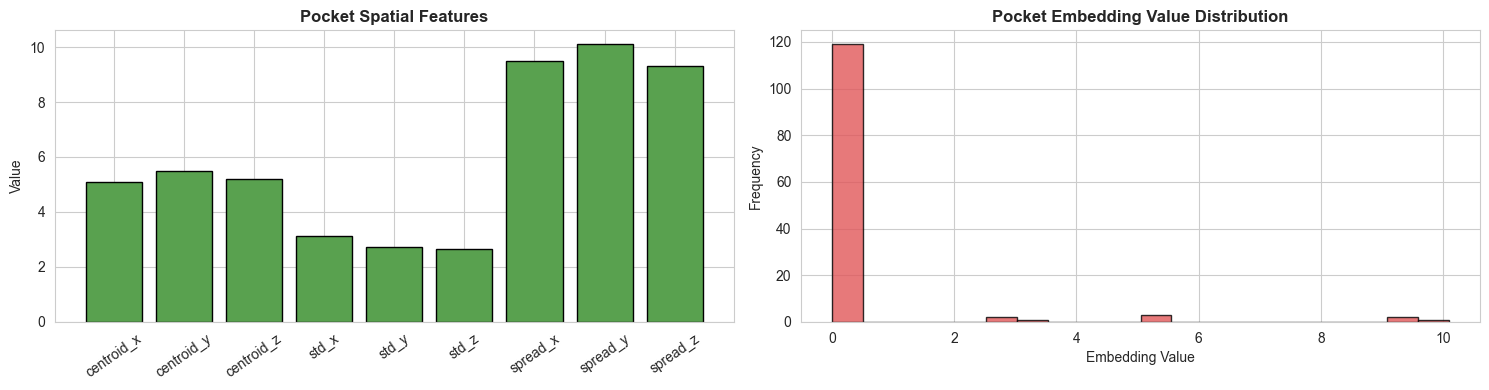

In [9]:
# ===== EDA: Pocket Feature Inspection =====

if 'pocket_embedding' in globals():
    pocket_array = pocket_embedding.detach().cpu().numpy().astype(float)
    pocket_labels = [
        'centroid_x', 'centroid_y', 'centroid_z',
        'std_x', 'std_y', 'std_z',
        'spread_x', 'spread_y', 'spread_z'
    ]
    pocket_df = pd.DataFrame({
        'Feature': pocket_labels + [f'pad_{i}' for i in range(len(pocket_array) - len(pocket_labels))],
        'Value': pocket_array
    })
    
    print('✓ Pocket embedding summary:')
    display(pd.DataFrame({
        'mean': [pocket_array.mean()],
        'std': [pocket_array.std()],
        'min': [pocket_array.min()],
        'max': [pocket_array.max()],
        'nonzero_count': [(pocket_array != 0).sum()]
    }))
    
    print('\n✓ Pocket feature values:')
    display(pocket_df.head(15))
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    
    axes[0].bar(pocket_labels, pocket_array[:9], color='#59A14F', edgecolor='black')
    axes[0].set_title('Pocket Spatial Features', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=35)
    axes[0].set_ylabel('Value')
    
    axes[1].hist(pocket_array, bins=20, color='#E15759', edgecolor='black', alpha=0.8)
    axes[1].set_title('Pocket Embedding Value Distribution', fontweight='bold')
    axes[1].set_xlabel('Embedding Value')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    pocket_out = OUT / 'pocket_feature_eda.png'
    plt.savefig(pocket_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved pocket feature EDA: {pocket_out}')
else:
    print('⚠ Pocket embedding not available yet; run the pocket encoding cell first')

✓ Visualizing graph topology for example molecules...
✓ Saved graph structure visualization: c:\Users\u2251865\Documents\u2251865\NSCLC_project\clean_data_diss\results\figures\graph_structure_examples.png

✓ Graph topology summary for selected examples:
  First Graph (index 0):
    - Nodes: 27, Edges: 60
    - Avg degree: 4.4
    - Has 3D coords: True
  Middle Graph (index 10454):
    - Nodes: 30, Edges: 66
    - Avg degree: 4.4
    - Has 3D coords: True
  Largest Graph (index 7251):
    - Nodes: 103, Edges: 220
    - Avg degree: 4.3
    - Has 3D coords: True


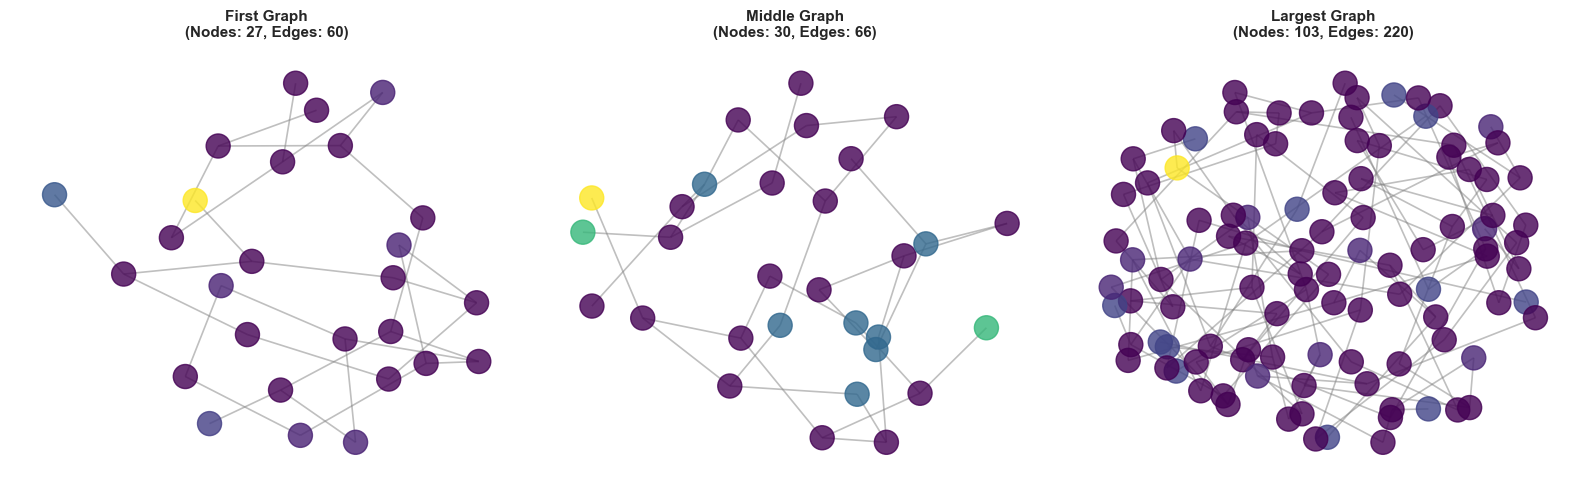

In [10]:
# ===== GRAPH STRUCTURE VISUALIZATION: NetworkX Examples =====

from torch_geometric.utils import to_networkx
import networkx as nx

if 'graphs' in globals() and len(graphs) > 2:
    print('✓ Visualizing graph topology for example molecules...')
    
    # Select example graphs (first, middle, one with most nodes)
    idx_first = 0
    idx_middle = len(graphs) // 2
    idx_largest = max(range(len(graphs)), key=lambda i: graphs[i].num_nodes)
    selected_indices = [idx_first, idx_middle, idx_largest]
    selected_graphs = [graphs[i] for i in selected_indices]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    titles = ['First Graph', 'Middle Graph', 'Largest Graph']
    
    for ax_idx, (g, title, orig_idx) in enumerate(zip(selected_graphs, titles, selected_indices)):
        # Convert to NetworkX
        G = to_networkx(g, to_undirected=True)
        
        # Compute layout
        pos = nx.spring_layout(G, seed=42, k=0.5, iterations=30)
        
        # Node colors based on atomic number (first feature)
        if hasattr(g, 'x') and g.x is not None:
            atomic_nums = g.x[:, 0].cpu().numpy().astype(int)
            node_colors = [atomic_nums[i] for i in range(len(atomic_nums))]
        else:
            node_colors = '#87CEEB'
        
        # Draw
        ax = axes[ax_idx]
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300,
                              cmap='viridis', ax=ax, alpha=0.8)
        nx.draw_networkx_edges(G, pos, width=1.2, alpha=0.5, ax=ax, edge_color='gray')
        
        ax.set_title(f'{title}\n(Nodes: {g.num_nodes}, Edges: {g.num_edges})',
                    fontweight='bold', fontsize=11)
        ax.axis('off')
    
    plt.tight_layout()
    graph_viz_out = OUT / 'graph_structure_examples.png'
    plt.savefig(graph_viz_out, dpi=300, bbox_inches='tight')
    print(f'✓ Saved graph structure visualization: {graph_viz_out}')
    
    # Print summary
    print('\n✓ Graph topology summary for selected examples:')
    for i, (g, title, orig_idx) in enumerate(zip(selected_graphs, titles, selected_indices)):
        print(f'  {title} (index {orig_idx}):')
        print(f'    - Nodes: {g.num_nodes}, Edges: {g.num_edges}')
        print(f'    - Avg degree: {2 * g.num_edges / g.num_nodes:.1f}')
        if hasattr(g, 'pos') and g.pos is not None:
            has_3d = torch.any(g.pos != 0).item()
            print(f'    - Has 3D coords: {has_3d}')
else:
    print('⚠ Graphs not available for visualization')
